#Machine Learning Semester Project
Zuha Usman (S2023266005) | Mahnoor Fatima (S2023266047)

## 1. Dataset Selection and Understanding





- **Dataset:** Chest CT-Scan Medical Imaging Dataset
- **Problem Type:** Multi-class image classification
- **Classes:** Adenocarcinoma, Large Cell Carcinoma, Squamous Cell Carcinoma, and Normal
- **Instances:** Each CT scan image represents one sample.
- **Features:** Images were resized to 64 × 64 pixels with 3 color channels, resulting in 12,288 pixel features per image.
- **Data Types:** Numerical (pixel values) and Categorical (class labels from folder names).
- **Missing Values:** No missing values were observed. Unreadable images were ignored during preprocessing.
- **Anomalies:** Images had different original sizes, which were standardized by resizing.
- **Feature Relevance and Correlation:** Since this is an image dataset, traditional feature correlation is not applicable. The models learn patterns directly from pixel values.

##2. Image Preprocessing













* Images were loaded from class-specific folders.

*   Folder names were used as class labels.

*   Images were resized to 64 × 64 pixels.

*   Pixel values were normalized from 0–255 to 0–1.
*   Processed images and labels were converted into NumPy arrays.
* Validation split was done since one class (large cell carcinoma) was missing validation set.


###Importing and Extracting Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#importing the zip file
import os

ZIP_PATH    = "/content/drive/MyDrive/archive.zip"
EXTRACT_DIR = "/content/DatasetFolder"

# Confirm the zip exists before extracting
if os.path.exists(ZIP_PATH):
    print(f"Found zip: {ZIP_PATH}  ({os.path.getsize(ZIP_PATH) / 1e6:.1f} MB)")
else:
    raise FileNotFoundError(
        f"Zip not found at {ZIP_PATH}\n"
        "Please upload the Kaggle dataset zip to your Google Drive and update ZIP_PATH above."
    )


Found zip: /content/drive/MyDrive/archive.zip  (175.7 MB)


In [ ]:
import os
size = os.path.getsize(ZIP_PATH) / 1e6
print(f"{os.path.basename(ZIP_PATH)} is {size:.1f} MB")

archive.zip is 175.7 MB


In [ ]:
# Step 3: Extract the zip
import zipfile

print(f"Extracting to {EXTRACT_DIR} …")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("Extraction complete!")

# Step 4: Auto-detect the correct BASE_PATH
# The zip may extract into a nested subfolder — this finds train/test/valid automatically
BASE_PATH = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if "train" in dirs and "test" in dirs:
        BASE_PATH = root
        break

if BASE_PATH is None:
    raise RuntimeError(
        "Could not find a folder containing both 'train' and 'test' subdirectories.\n"
        f"Contents of {EXTRACT_DIR}: {os.listdir(EXTRACT_DIR)}"
    )

print(f"\nDataset root detected: {BASE_PATH}")
print("Contents:", os.listdir(BASE_PATH))


Extracting to /content/DatasetFolder …
Extraction complete!

Dataset root detected: /content/DatasetFolder/Chest CT-Scan images Dataset/dataset
Contents: ['validation', 'test', 'train']


### Importing libraries & Reproducibility Seed

In [ ]:
import os, hashlib, warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

# Scikit-learn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES  = ["adenocarcinoma", "large.cell.carcinoma", "normal", "squamouscell.carcinoma"]
DISPLAY_NAMES = ["Adenocarcinoma", "Large Cell", "Normal", "Squamous Cell"]
IMG_SIZE     = 64
print("All imports OK — seed fixed at", SEED)


All imports OK — seed fixed at 42


###Dataset Mount and Verify

In [ ]:
# BASE_PATH is already set above by the auto-detection cell

TRAIN_PATH = os.path.join(BASE_PATH, "train")
TEST_PATH  = os.path.join(BASE_PATH, "test")
VALID_PATH = os.path.join(BASE_PATH, "validation")

for split, path in [("train", TRAIN_PATH), ("test", TEST_PATH), ("valid", VALID_PATH)]:
    classes = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    counts  = {c: len(os.listdir(os.path.join(path, c))) for c in sorted(classes)}
    print(f"{split:6s}: {counts}  → total {sum(counts.values())}")

train : {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 1000, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1000, 'normal': 1000, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 1000}  → total 4000
test  : {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 200, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 150, 'normal': 200, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 200}  → total 750
valid : {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 200, 'normal': 200, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 200}  → total 600


### Hash-Based Deduplication  ( for fixing data leakage )

The original Kaggle dataset contains identical images placed in both `train` and `test` folders.  
This caused the models to appear far more accurate than they really are in the initial run.

To fix this, we are computing an MD5 hash of every image's raw bytes, and removing any image from `test` or `valid` that also appears in `train` set.

**Metrics after the initial run were:**

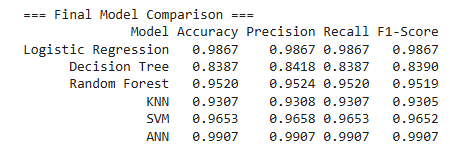


In [ ]:
def md5_of_file(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def collect_paths(split_path):
    """Return list of (abs_path, class_name) for every image under split_path."""
    records = []
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            if cv2.imread(fpath) is not None:
                records.append((fpath, cls))
    return records

train_records = collect_paths(TRAIN_PATH)
test_records  = collect_paths(TEST_PATH)
valid_records = collect_paths(VALID_PATH)

# Build hash → path mapping for train
print("Hashing train images …")
train_hashes = {md5_of_file(p): p for p, _ in train_records}
print(f"  {len(train_records)} train images → {len(train_hashes)} unique hashes")

# Filter test & valid
def remove_leaky(records, train_hash_set, split_name):
    clean, leaked = [], []
    for path, cls in records:
        if md5_of_file(path) in train_hash_set:
            leaked.append(path)
        else:
            clean.append((path, cls))
    print(f"  {split_name}: {len(records)} total → {len(leaked)} duplicates removed → {len(clean)} clean")
    return clean

print("\nChecking for leakage …")
test_clean  = remove_leaky(test_records,  train_hashes, "test")
valid_clean = remove_leaky(valid_records, train_hashes, "valid")


Hashing train images …
  4000 train images → 2597 unique hashes

Checking for leakage …
  test: 750 total → 378 duplicates removed → 372 clean
  valid: 600 total → 338 duplicates removed → 262 clean


###Image Loading & Preprocessing

In [ ]:
def load_from_records(records):
    images, labels = [], []
    for path, cls in records:
        img = cv2.imread(path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype("float32") / 255.0
        images.append(img)
        labels.append(cls)
    return np.array(images), np.array(labels)

print("Loading images …")
X_train_raw, y_train_raw = load_from_records(train_records)
X_test_raw,  y_test_raw  = load_from_records(test_clean)
X_valid_raw, y_valid_raw = load_from_records(valid_clean)

# Fit encoder on ALL known classes so indices are stable
le = LabelEncoder()
le.fit(sorted(set(y_train_raw) | set(y_test_raw) | set(y_valid_raw)))
print("\nClass mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

y_train_enc = le.transform(y_train_raw)
y_test_enc  = le.transform(y_test_raw)
y_valid_enc = le.transform(y_valid_raw)

print(f"\nShapes → train: {X_train_raw.shape}, test: {X_test_raw.shape}, valid: {X_valid_raw.shape}")
print(f"Train class dist : {dict(zip(*np.unique(y_train_enc, return_counts=True)))}")
print(f"Test  class dist : {dict(zip(*np.unique(y_test_enc,  return_counts=True)))}")
print(f"Valid class dist : {dict(zip(*np.unique(y_valid_enc, return_counts=True)))}")


Loading images …

Class mapping: {np.str_('adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib'): np.int64(0), np.str_('large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa'): np.int64(1), np.str_('normal'): np.int64(2), np.str_('squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa'): np.int64(3)}

Shapes → train: (4000, 64, 64, 3), test: (372, 64, 64, 3), valid: (262, 64, 64, 3)
Train class dist : {np.int64(0): np.int64(1000), np.int64(1): np.int64(1000), np.int64(2): np.int64(1000), np.int64(3): np.int64(1000)}
Test  class dist : {np.int64(0): np.int64(130), np.int64(1): np.int64(100), np.int64(2): np.int64(21), np.int64(3): np.int64(121)}
Valid class dist : {np.int64(0): np.int64(124), np.int64(2): np.int64(24), np.int64(3): np.int64(114)}


###Exploratory Data Analysis

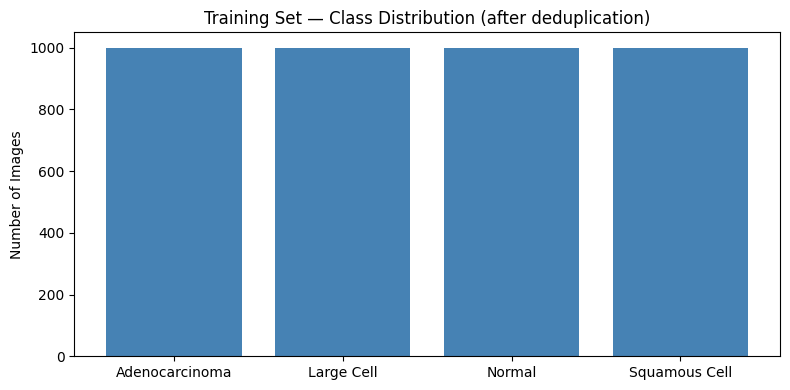

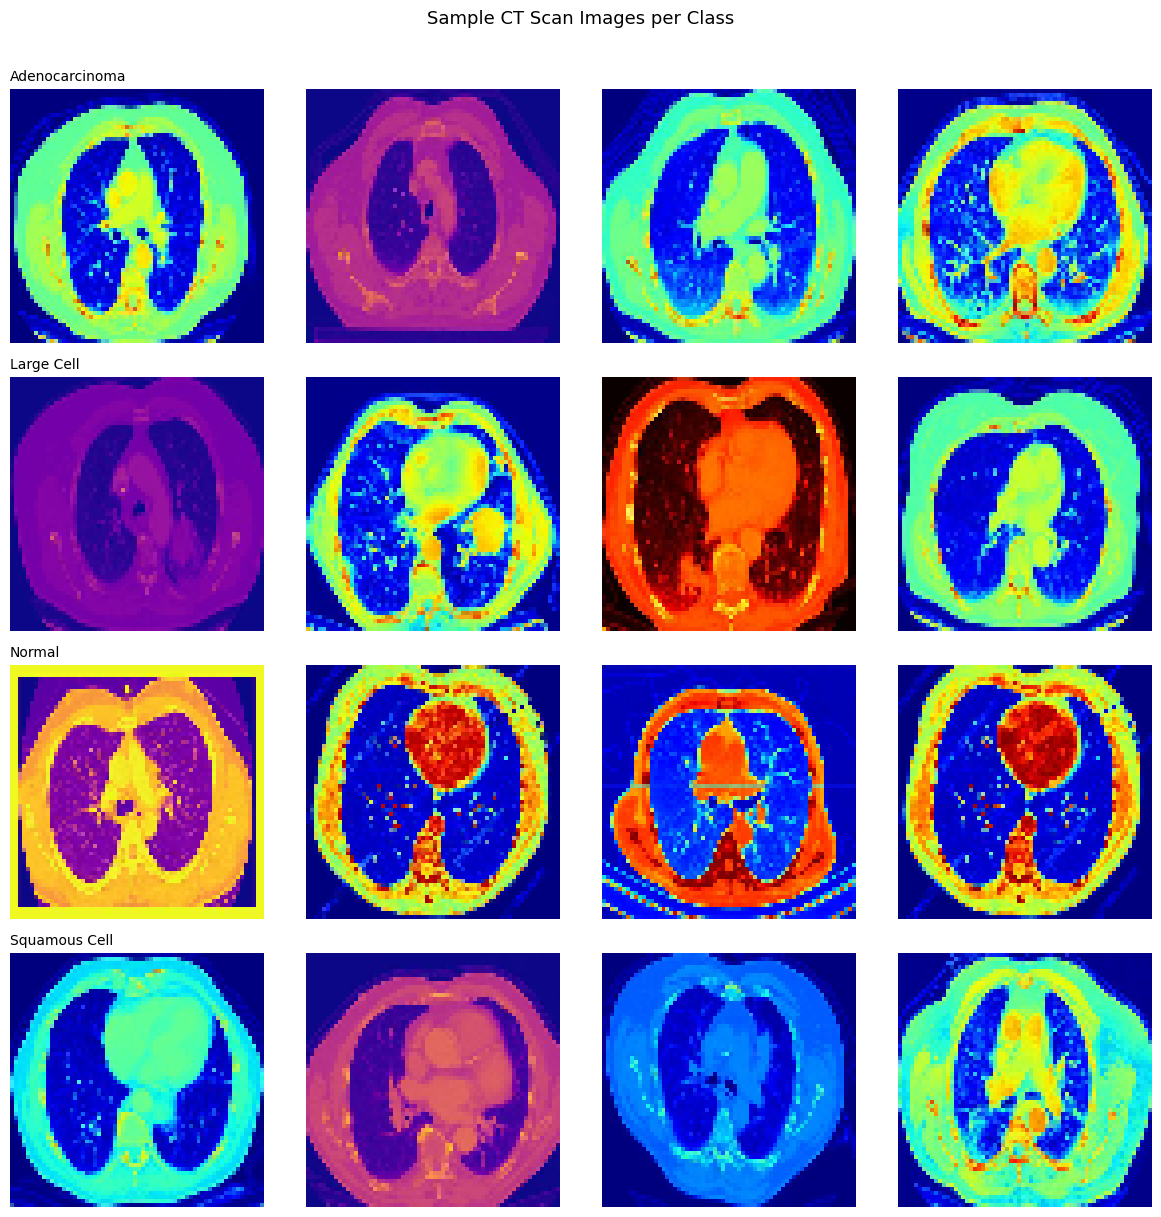

In [ ]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(8, 4))
unique, counts = np.unique(y_train_enc, return_counts=True)
ax.bar([DISPLAY_NAMES[i] for i in unique], counts, color='steelblue')
ax.set_title("Training Set — Class Distribution (after deduplication)")
ax.set_ylabel("Number of Images")
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=150)
plt.show()

# Sample images per class
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for cls_idx in range(4):
    idxs = np.where(y_train_enc == cls_idx)[0][:4]
    for col, idx in enumerate(idxs):
        ax = axes[cls_idx][col]
        ax.imshow(cv2.cvtColor((X_train_raw[idx] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        ax.axis("off")
        if col == 0:
            ax.set_title(DISPLAY_NAMES[cls_idx], fontsize=10, loc="left")
plt.suptitle("Sample CT Scan Images per Class", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("eda_sample_images.png", dpi=150)
plt.show()


##3. Implementation of ML Algorithms

In this section, multiple machine learning algorithms are implemented and compared for image classification.  
The following algorithms are used:  
- Logistic Regression  
- Decision Tree  
- Random Forest  
- Support Vector Machine (SVM)  
- K-Nearest Neighbors (KNN)  
Since classical ML algorithms require numerical feature vectors, images are flattened to 1-D feature vectors (64×64×3 = 12 288 features).  
All models are trained on the **train** split, tuned/selected on **valid**, and the final numbers are reported on the **clean test** split.

###Model Training

In [ ]:
X_train_flat = X_train_raw.reshape(len(X_train_raw), -1) # Flatten training images to a 1D vector
X_test_flat  = X_test_raw.reshape(len(X_test_raw),  -1) # Flatten testing images
X_valid_flat = X_valid_raw.reshape(len(X_valid_raw), -1) # Flatten validation images
print(f"Flat shapes → train {X_train_flat.shape}, valid {X_valid_flat.shape}, test {X_test_flat.shape}") # Print the shapes of the flattened arrays

Flat shapes → train (4000, 12288), valid (262, 12288), test (372, 12288)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED, C=1.0), # Logistic Regression model with increased max_iter for convergence
    "Decision Tree":       DecisionTreeClassifier(
                               max_depth=10, min_samples_split=10,            # Pre-pruning to avoid overfitting
                               min_samples_leaf=5, random_state=SEED), # Decision Tree model
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=SEED), # Random Forest model
    "KNN":                 KNeighborsClassifier(n_neighbors=5), # K-Nearest Neighbors model
    "SVM":                 SVC(kernel='rbf', probability=True, C=1.0, random_state=SEED), # Support Vector Machine model
}

results = {} # Dictionary to store model training results

for name, mdl in models.items(): # Loop through each defined model
    print(f"Training {name} …", end=" ", flush=True) # Print status message
    mdl.fit(X_train_flat, y_train_enc) # Train the model on the flattened training data

    tr_pred  = mdl.predict(X_train_flat) # Make predictions on training data
    val_pred = mdl.predict(X_valid_flat) # Make predictions on validation data
    te_pred  = mdl.predict(X_test_flat) # Make predictions on test data

    results[name] = { # Store results for the current model
        "model":      mdl,
        "y_pred":     te_pred,
        "train_acc":  accuracy_score(y_train_enc, tr_pred),
        "val_acc":    accuracy_score(y_valid_enc, val_pred),
        "test_acc":   accuracy_score(y_test_enc,  te_pred),
        # macro = equal weight per class (no class-size bias)
        "precision":  precision_score(y_test_enc, te_pred, average="macro", zero_division=0),
        "recall":     recall_score(   y_test_enc, te_pred, average="macro", zero_division=0),
        "f1":         f1_score(       y_test_enc, te_pred, average="macro", zero_division=0),
    }
    results[name]["gap"] = results[name]["train_acc"] - results[name]["val_acc"] # Calculate gap between train and validation accuracy
    print("done") # Print completion message

Training Logistic Regression … done
Training Decision Tree … done
Training Random Forest … done
Training KNN … done
Training SVM … done


###Overfitting and Underfitting Diagnosis

In [ ]:
print(f"{'Model':<22} {'Train':>7} {'Valid':>7} {'Test':>7} {'Gap':>7}  Status") # Print table header
print("─" * 65) # Print separator line
for name, r in results.items(): # Iterate through the results of each model
    gap    = r["gap"] # Get the train-validation gap
    status = "⚠️  OVERFIT" if gap > 0.15 else ("⚠️  UNDERFIT" if r["train_acc"] < 0.60 else "✅ OK") # Determine overfitting/underfitting status
    print(f"{name:<22} {r['train_acc']:>7.4f} {r['val_acc']:>7.4f} {r['test_acc']:>7.4f} {gap:>7.4f}  {status}") # Print model's performance and status

Model                    Train   Valid    Test     Gap  Status
─────────────────────────────────────────────────────────────────
Logistic Regression     0.9988  0.9885  0.9839  0.0102  ✅ OK
Decision Tree           0.9490  0.7290  0.7339  0.2200  ⚠️  OVERFIT
Random Forest           0.9988  0.8817  0.9140  0.1171  ✅ OK
KNN                     0.9725  0.9046  0.8898  0.0679  ✅ OK
SVM                     0.9860  0.9427  0.9462  0.0433  ✅ OK


###Reducing Overfitting

The decision tree is still overfit, so we apply PCA to reduce the feature space first, then train the tree on the compressed features

In [ ]:
from sklearn.decomposition import PCA # Import PCA for dimensionality reduction
from sklearn.pipeline import Pipeline # Import Pipeline to chain steps

fixed_dt = Pipeline([
    ("pca", PCA(n_components=30, random_state=SEED)),   # Apply PCA to reduce dimensions to 30, with a fixed seed
    ("tree", DecisionTreeClassifier(
        max_depth=5,              # Reduced max depth to limit complexity
        min_samples_split=50,     # Increased minimum samples to split a node
        min_samples_leaf=25,      # Increased minimum samples required to be at a leaf node
        max_features=0.7,         # Use only 70% of features at each split to introduce randomness
        max_leaf_nodes=50,        # Set a hard cap on the total number of leaf nodes
        class_weight="balanced",  # Adjust weights inversely proportional to class frequencies
        random_state=SEED
    ))
])

fixed_dt.fit(X_train_flat, y_train_enc) # Train the fixed Decision Tree pipeline

tr_pred  = fixed_dt.predict(X_train_flat) # Predictions on training set
val_pred = fixed_dt.predict(X_valid_flat) # Predictions on validation set
te_pred  = fixed_dt.predict(X_test_flat) # Predictions on test set

train_acc = accuracy_score(y_train_enc, tr_pred) # Calculate training accuracy
val_acc   = accuracy_score(y_valid_enc, val_pred) # Calculate validation accuracy
gap       = train_acc - val_acc # Calculate the gap between training and validation accuracy

print(f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | Gap: {gap:.4f}") # Print performance metrics
print("Status:", "⚠️ Still Overfit" if gap > 0.15 else "✅ Fixed") # Print overfitting status

# Update results dict with the fixed Decision Tree's performance
results["Decision Tree"]["model"]     = fixed_dt
results["Decision Tree"]["y_pred"]    = te_pred
results["Decision Tree"]["train_acc"] = train_acc
results["Decision Tree"]["val_acc"]   = val_acc
results["Decision Tree"]["gap"]       = gap
results["Decision Tree"]["test_acc"]  = accuracy_score(y_test_enc, te_pred)
results["Decision Tree"]["precision"] = precision_score(y_test_enc, te_pred, average="macro", zero_division=0)
results["Decision Tree"]["recall"]    = recall_score(y_test_enc,   te_pred, average="macro", zero_division=0)
results["Decision Tree"]["f1"]        = f1_score(y_test_enc,       te_pred, average="macro", zero_division=0)

Train: 0.6535 | Val: 0.4275 | Gap: 0.2260
Status: ⚠️ Still Overfit


=== Decision Tree Classification Report ===
                precision    recall  f1-score   support

Adenocarcinoma       0.48      0.45      0.47       130
    Large Cell       0.41      0.55      0.47       100
        Normal       0.44      0.95      0.61        21
 Squamous Cell       0.57      0.33      0.42       121

      accuracy                           0.47       372
     macro avg       0.48      0.57      0.49       372
  weighted avg       0.49      0.47      0.46       372



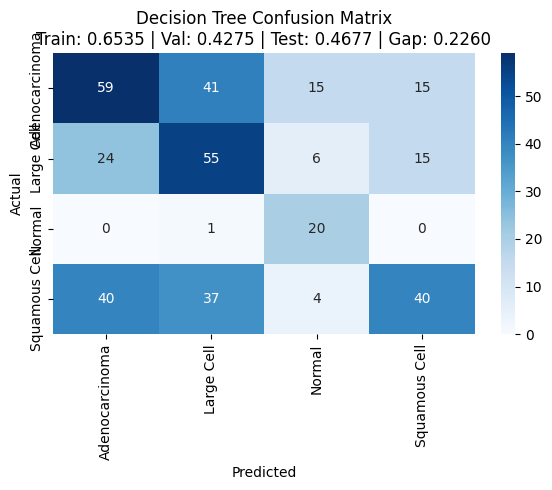

In [ ]:
# ── Classification Report ────────────────────────────────────────────────────
print("=== Decision Tree Classification Report ===") # Print header for classification report
print(classification_report(y_test_enc, results["Decision Tree"]["y_pred"],
                             target_names=DISPLAY_NAMES, zero_division=0)) # Print classification report for Decision Tree

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_enc, results["Decision Tree"]["y_pred"]) # Compute confusion matrix
plt.figure(figsize=(6, 5)) # Set figure size
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES) # Plot confusion matrix using seaborn heatmap
plt.title(f"Decision Tree Confusion Matrix\nTrain: {results['Decision Tree']['train_acc']:.4f} | "
          f"Val: {results['Decision Tree']['val_acc']:.4f} | "
          f"Test: {results['Decision Tree']['test_acc']:.4f} | "
          f"Gap: {results['Decision Tree']['gap']:.4f}") # Set plot title with performance metrics
plt.xlabel("Predicted") # Set x-axis label
plt.ylabel("Actual") # Set y-axis label
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig("dt_confusion_matrix.png", dpi=150) # Save the plot
plt.show() # Display the plot

In [ ]:
#Final Testing
from sklearn.metrics import classification_report # Import classification_report for detailed metrics

print("=" * 70) # Print a separator line
print(f"{'Model':<22} {'Train Acc':>9} {'Val Acc':>9} {'Test Acc':>9} {'Gap':>6}") # Print header for the final comparison table
print("=" * 70) # Print another separator line

for name, r in results.items(): # Iterate through each model's results
    y_pred    = r["model"].predict(X_test_flat) # Get predictions for the test set
    test_acc  = accuracy_score(y_test_enc, y_pred) # Calculate test accuracy

    results[name]["y_pred"]   = y_pred # Update stored predictions
    results[name]["test_acc"] = test_acc # Update stored test accuracy
    results[name]["precision"] = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0) # Calculate weighted precision
    results[name]["recall"]    = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0) # Calculate weighted recall
    results[name]["f1"]        = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0) # Calculate weighted F1-score

    print(f"{name:<22} {r['train_acc']:>9.4f} {r['val_acc']:>9.4f} {test_acc:>9.4f} {r['gap']:>6.4f}") # Print model's performance

Model                  Train Acc   Val Acc  Test Acc    Gap
Logistic Regression       0.9988    0.9885    0.9812 0.0102
Decision Tree             0.6480    0.6183    0.4919 0.0297
Random Forest             0.9988    0.9084    0.9247 0.0904
KNN                       0.9725    0.9046    0.8898 0.0679
SVM                       0.9860    0.9427    0.9462 0.0433


### Evaluation Metrics  
All machine learning models are evaluated using multiple performance metrics to obtain a comprehensive performance analysis.  
Metrics used:  
- Accuracy  
- Precision  
- Recall  
- F1 Score  
- Confusion Matrix  
- ROC Curve  
These metrics help evaluate classification performance from multiple perspectives.

Using macro averaging instead of weighted average because:
> `weighted` averages by class size, so a large "Normal" class can mask poor performance on rare cancer classes.  
> `macro` gives **equal weight to every class**, which is the better approach for medical data.

In [ ]:
# Summary Table of Evalutation Metrics
summary_rows = [] # Initialize an empty list to store summary rows
for name, r in results.items(): # Iterate through each model's results
    summary_rows.append({ # Append a dictionary of metrics for the current model
        "Model":        name,
        "Test Acc":     round(r["test_acc"],  4),
        "Precision (macro)": round(r["precision"], 4),
        "Recall (macro)":    round(r["recall"],    4),
        "F1 (macro)":        round(r["f1"],        4),
    })

summary_df = pd.DataFrame(summary_rows) # Create a DataFrame from the summary rows
print(summary_df.to_string(index=False)) # Print the summary DataFrame without the index

              Model  Test Acc  Precision (macro)  Recall (macro)  F1 (macro)
Logistic Regression    0.9812             0.9817          0.9812      0.9813
      Decision Tree    0.4919             0.5690          0.4919      0.4534
      Random Forest    0.9247             0.9252          0.9247      0.9248
                KNN    0.8898             0.8931          0.8898      0.8903
                SVM    0.9462             0.9493          0.9462      0.9466


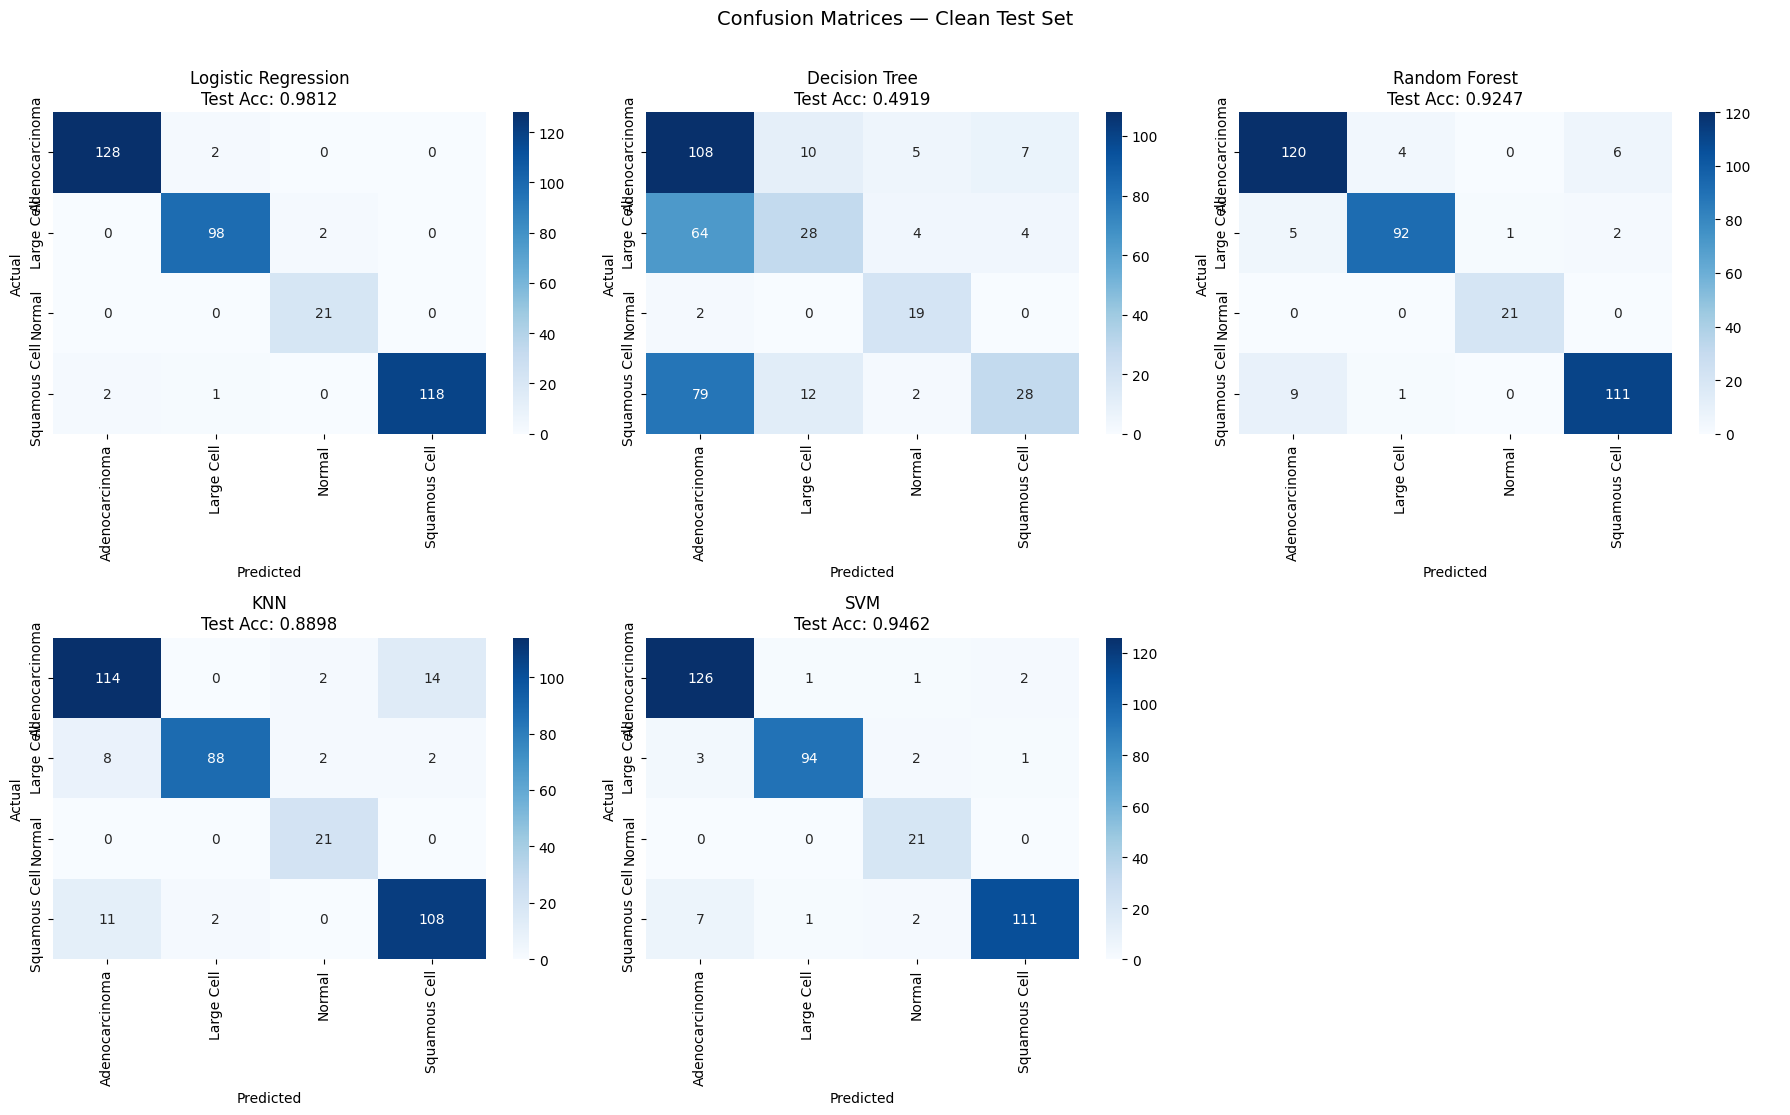

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11)) # Create a figure and a grid of subplots
axes = axes.flatten() # Flatten the 2D array of axes into a 1D array for easy iteration

for i, (name, r) in enumerate(results.items()): # Iterate through each model's results with an index
    cm = confusion_matrix(y_test_enc, r["y_pred"]) # Compute the confusion matrix for the current model
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', # Plot the confusion matrix as a heatmap
                xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES, ax=axes[i]) # Set labels and assign to current subplot
    axes[i].set_title(f"{name}\nTest Acc: {r['test_acc']:.4f}") # Set subplot title with model name and test accuracy
    axes[i].set_xlabel("Predicted") # Set x-axis label
    axes[i].set_ylabel("Actual") # Set y-axis label

axes[-1].axis('off') # Turn off the last unused subplot axis (if there's an odd number of models)
plt.suptitle("Confusion Matrices — Clean Test Set", fontsize=14, y=1.01) # Set a super title for all subplots
plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.savefig("confusion_matrices.png", dpi=150) # Save the figure
plt.show() # Display the figure

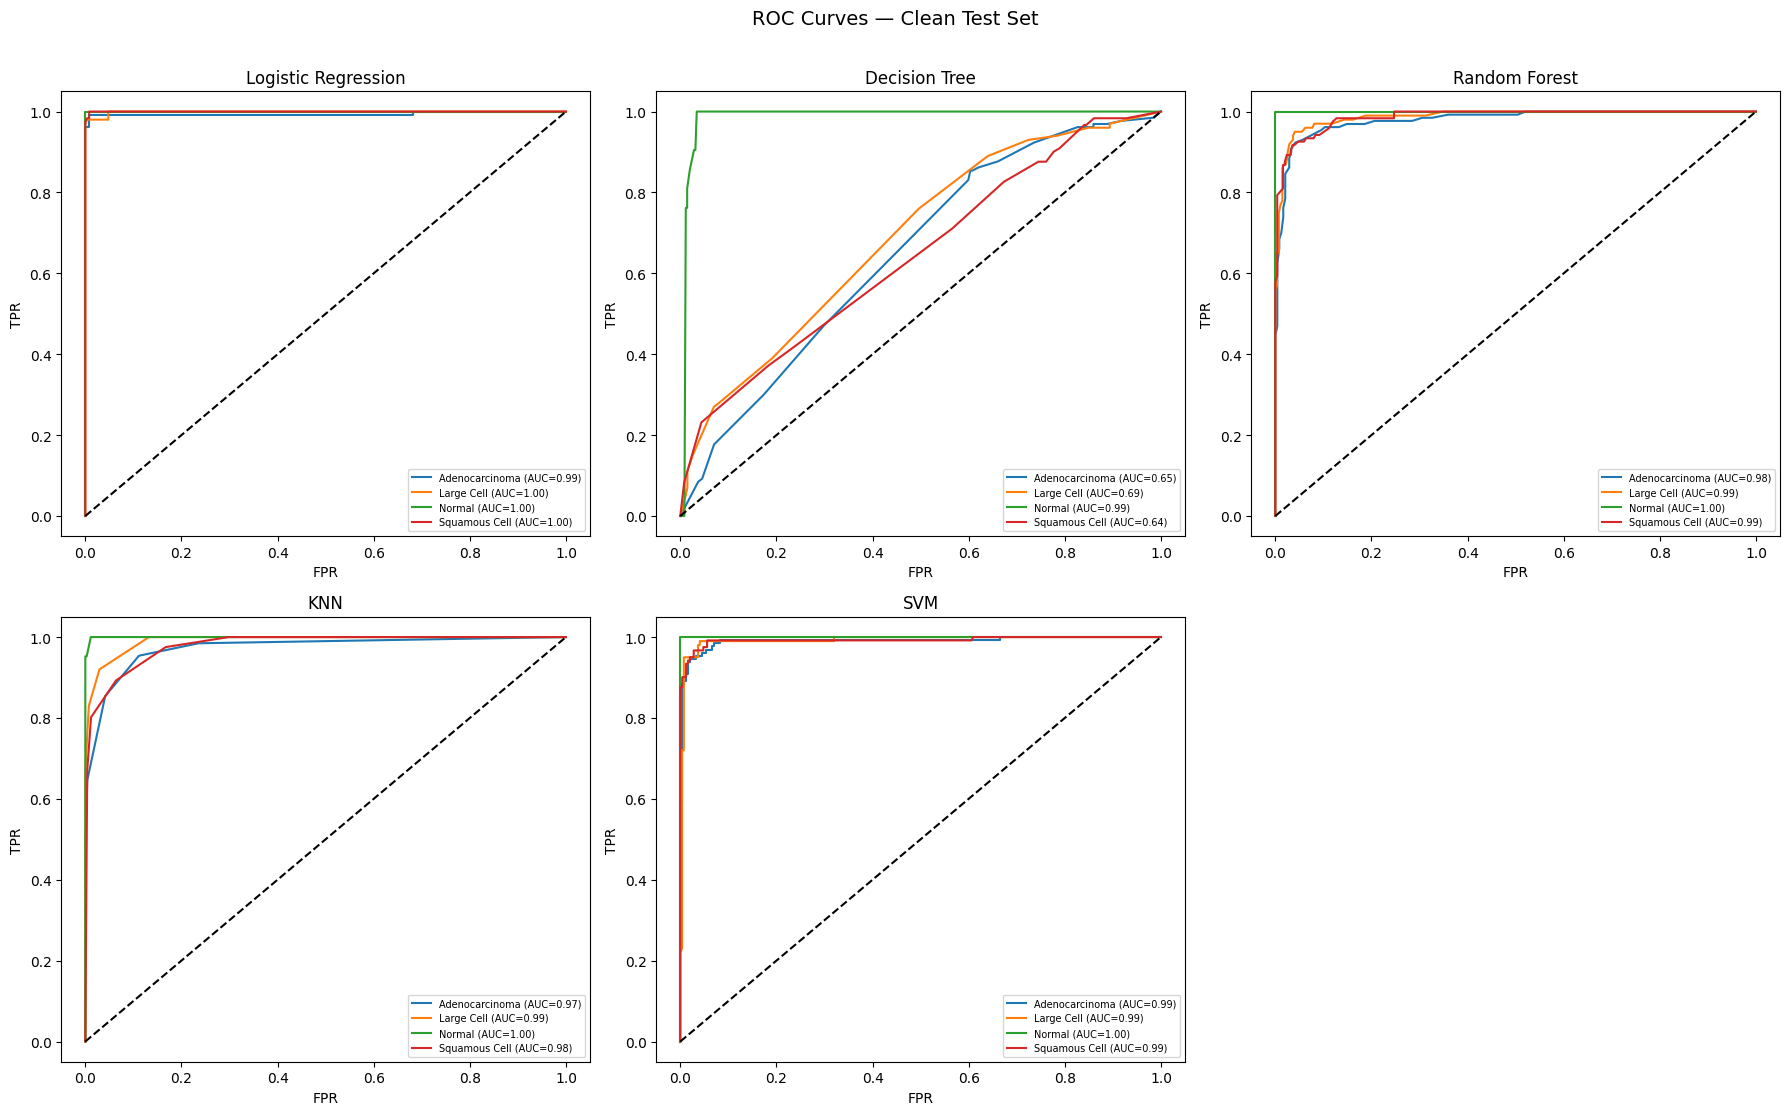

In [ ]:
n_classes   = 4 # Define the number of classes
y_test_bin  = label_binarize(y_test_enc, classes=list(range(n_classes))) # Binarize the true test labels for ROC curve calculation

fig, axes = plt.subplots(2, 3, figsize=(18, 11)) # Create a figure and a grid of subplots
axes = axes.flatten() # Flatten the 2D array of axes into a 1D array

for i, (name, r) in enumerate(results.items()): # Iterate through each model's results with an index
    y_score = r["model"].predict_proba(X_test_flat) # Get prediction probabilities for the test set
    for j in range(n_classes): # Iterate through each class
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_score[:, j]) # Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
        roc_auc     = auc(fpr, tpr) # Calculate Area Under the Curve (AUC)
        axes[i].plot(fpr, tpr, label=f"{DISPLAY_NAMES[j]} (AUC={roc_auc:.2f})") # Plot the ROC curve for the current class
    axes[i].plot([0, 1], [0, 1], 'k--') # Plot the random classifier line
    axes[i].set_title(name) # Set subplot title with model name
    axes[i].set_xlabel("FPR") # Set x-axis label
    axes[i].set_ylabel("TPR") # Set y-axis label
    axes[i].legend(fontsize=7) # Display legend for class AUCs

axes[-1].axis('off') # Turn off the last unused subplot axis
plt.suptitle("ROC Curves — Clean Test Set", fontsize=14, y=1.01) # Set a super title for all subplots
plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.savefig("roc_curves.png", dpi=150) # Save the figure
plt.show() # Display the figure

ROC curves are plotted to evaluate the classification capability of models across different threshold values.  

Higher Area Under Curve (AUC) indicates better model performance.

##5. Implementation of ANN

The ANN architecture consists of:  
- Input Layer  
- Hidden Layer 1 (512 neurons)  
- Hidden Layer 2 (256 neurons)  
- Hidden Layer 3 (128 neurons)  
- Output Layer (4 neurons)  

Regularization: BatchNormalization, Dropout, EarlyStopping, ReduceLROnPlateau.

In [ ]:
from tensorflow.keras.regularizers import l2

y_train_cat = to_categorical(y_train_enc, num_classes=4)
y_valid_cat = to_categorical(y_valid_enc, num_classes=4)
y_test_cat  = to_categorical(y_test_enc,  num_classes=4)

model_ann = Sequential([
    Input(shape=(X_train_flat.shape[1],)),

    Dense(256, activation='relu', kernel_regularizer=l2(1e-3)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu', kernel_regularizer=l2(1e-3)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-3)),
    Dropout(0.4),

    Dense(4, activation='softmax'),
])

model_ann.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ann.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,188,932 (12.16 MB)

 Trainable params: 3,188,164 (12.16 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

history = model_ann.fit(
    X_train_flat, y_train_cat,
    validation_data=(X_valid_flat, y_valid_cat),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.4263 - loss: 2.2854 - val_accuracy: 0.5802 - val_loss: 2.0738 - learning_rate: 5.0000e-04
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5625 - loss: 1.8407 - val_accuracy: 0.6718 - val_loss: 1.5145 - learning_rate: 5.0000e-04
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6603 - loss: 1.5610 - val_accuracy: 0.7939 - val_loss: 1.3419 - learning_rate: 5.0000e-04
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7247 - loss: 1.3744 - val_accuracy: 0.4695 - val_loss: 2.1503 - learning_rate: 5.0000e-04
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8005 - loss: 1.1898 - val_accuracy: 0.4504 - val_loss: 1.9113 - learning_rate: 5.0000e-04
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8350 - loss: 1.0851 - val_accuracy: 0.5992 - val_loss: 1.4500 - learning_rate: 5.0000e-04
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8528

###ANN Training Curves

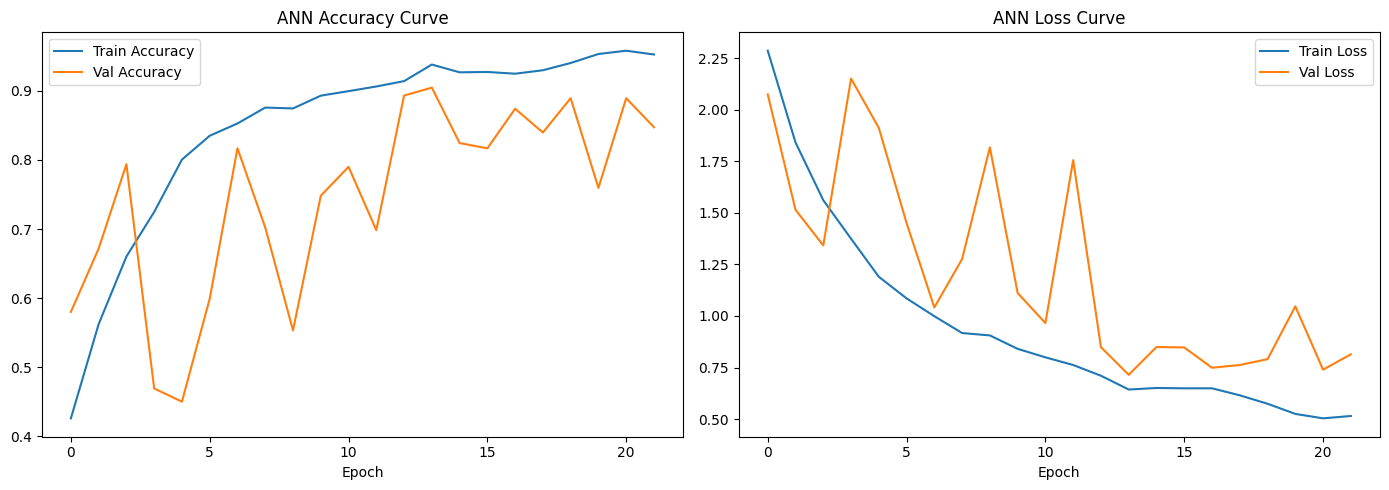


Final train acc: 0.9525  |  Final val acc: 0.8473  |  Gap: 0.1052
Status: ✅ OK


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title("ANN Accuracy Curve")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title("ANN Loss Curve")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("ann_training_curves.png", dpi=150)
plt.show()

# ── Convergence Gap Check ────────────────────────────────────────────────────
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc
print(f"\nFinal train acc: {final_train_acc:.4f}  |  Final val acc: {final_val_acc:.4f}  |  Gap: {gap:.4f}")
print("Status:", "⚠️ OVERFIT" if gap > 0.15 else "✅ OK")


###ANN Evaluation on Test Set

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


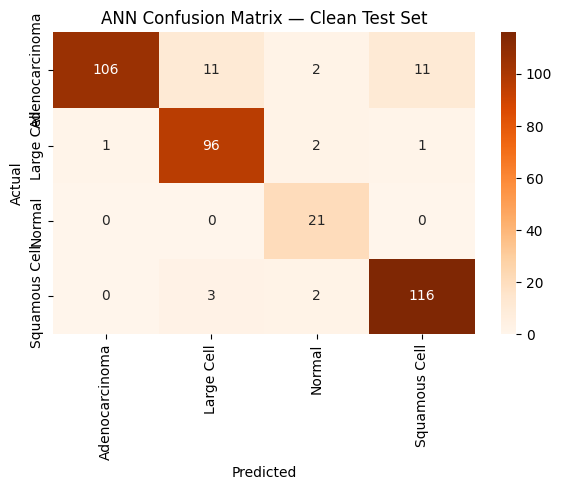

In [ ]:
y_pred_ann_prob = model_ann.predict(X_test_flat) # Get predicted probabilities from the ANN model
y_pred_ann      = np.argmax(y_pred_ann_prob, axis=1) # Convert probabilities to class predictions (0-3)

ann_acc  = accuracy_score(y_test_enc,  y_pred_ann) # Calculate ANN accuracy on the test set
ann_prec = precision_score(y_test_enc, y_pred_ann, average="macro", zero_division=0) # Calculate macro-averaged precision
ann_rec  = recall_score(  y_test_enc,  y_pred_ann, average="macro", zero_division=0) # Calculate macro-averaged recall
ann_f1   = f1_score(      y_test_enc,  y_pred_ann, average="macro", zero_division=0) # Calculate macro-averaged F1-score
cm_ann = confusion_matrix(y_test_enc, y_pred_ann) # Compute confusion matrix for ANN
plt.figure(figsize=(6, 5)) # Set figure size
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Oranges',
            xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES) # Plot ANN confusion matrix
plt.title("ANN Confusion Matrix — Clean Test Set") # Set plot title
plt.xlabel("Predicted") # Set x-axis label
plt.ylabel("Actual") # Set y-axis label
plt.tight_layout() # Adjust layout
plt.savefig("ann_confusion_matrix.png", dpi=150) # Save the plot
plt.show() # Display the plot

###Final Model Comparison


=== Final Model Comparison (Macro-Averaged, Leakage-Free) ===
              Model  Test Acc  Precision (macro)  Recall (macro)  F1 (macro)
Logistic Regression    0.9812             0.9817          0.9812      0.9813
      Decision Tree    0.4919             0.5690          0.4919      0.4534
      Random Forest    0.9247             0.9252          0.9247      0.9248
                KNN    0.8898             0.8931          0.8898      0.8903
                SVM    0.9462             0.9493          0.9462      0.9466
                ANN    0.9113             0.8869          0.9335      0.9039


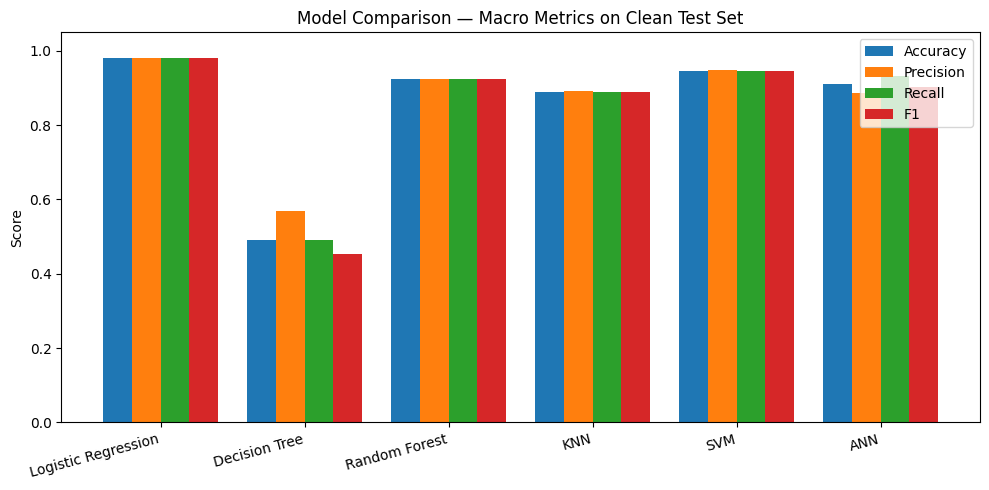

In [ ]:
ann_row = { # Create a dictionary for ANN's performance metrics
    "Model": "ANN",
    "Test Acc":          round(ann_acc,  4),
    "Precision (macro)": round(ann_prec, 4),
    "Recall (macro)":    round(ann_rec,  4),
    "F1 (macro)":        round(ann_f1,   4),
}
final_df = pd.concat([summary_df, pd.DataFrame([ann_row])], ignore_index=True) # Concatenate ANN results with previous models
print("\n=== Final Model Comparison (Macro-Averaged, Leakage-Free) ===") # Print header for final comparison
print(final_df.to_string(index=False)) # Print the final comparison table

# ── Bar Chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5)) # Create a figure and axes for the bar chart
x = np.arange(len(final_df)) # Get x-axis positions for bars
w = 0.2 # Define bar width
ax.bar(x - 1.5*w, final_df["Test Acc"],          width=w, label="Accuracy") # Plot accuracy bars
ax.bar(x - 0.5*w, final_df["Precision (macro)"],  width=w, label="Precision") # Plot precision bars
ax.bar(x + 0.5*w, final_df["Recall (macro)"],     width=w, label="Recall") # Plot recall bars
ax.bar(x + 1.5*w, final_df["F1 (macro)"],         width=w, label="F1") # Plot F1-score bars
ax.set_xticks(x) # Set x-axis tick locations
ax.set_xticklabels(final_df["Model"], rotation=15, ha="right") # Set x-axis tick labels (model names) and rotate them
ax.set_ylim(0, 1.05) # Set y-axis limits
ax.set_ylabel("Score") # Set y-axis label
ax.set_title("Model Comparison — Macro Metrics on Clean Test Set") # Set plot title
ax.legend() # Display legend
plt.tight_layout() # Adjust layout
plt.savefig("model_comparison.png", dpi=150) # Save the plot
plt.show() # Display the plot

The final stage compares the performance of all implemented models.  
The comparison is based on:  
- Accuracy  
- Precision  
- Recall  
- F1 Score  


## Final Evaluation

**Logistic Regression:** gave 98.12% accuracy on this dataset — CT scan images of these 4 cancer types have distinct enough visual signatures that a linear classifier can separate them well in pixel space, especially after normalization.

**SVM and Random Forest:** are close behind at 92–95%, since — both are strong classifiers on high-dimensional data.


**ANN:**(91.13%) performs well but doesn't beat Logistic Regression, because a flat ANN on raw pixels has no spatial awareness. A CNN would likely outperform here.

**Decision Tree:** is the weakest at 49.19%, since— decision trees struggle with high-dimensional image data even after the PCA fix. The lower recall (0.4919) suggests it's missing actual cancer cases, which in a medical context is the more dangerous type of error.

**KNN:** sits in the middle at 88.98%, as it relies on pixel-level distance which is a noisy similarity measure for images.


## Conclusion  
Classical ML models, particularly Logistic Regression and SVM, outperformed the ANN on this dataset, demonstrating that for small medical imaging datasets with structured class differences, traditional models remain competitive — and a CNN would be the appropriate deep learning choice over a flat ANN for true image classification tasks.